## Experiment Overview
This notebook analyzes the results of a targeted attack experiment. It evaluates different configurations and summarizes their performance using predefined metrics.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
from pathlib import Path


PROJECT_ROOT = Path("/content/drive/MyDrive/master-thesis").resolve()

SRC_PATH = PROJECT_ROOT / "src"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"

os.chdir(PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.targeted_experiment_utils import (
    ATSSetup,
    TARGET_SIGNALS,
    build_attack_day_plan,
    compute_summary_by_setup_and_timing,
    compute_timing_summaries,
    compute_summary_by_setup,
    run_targeted_attack_experiment,
)

MODEL_FOLDERS = {
    "LSTM": NOTEBOOK_DIR / "models/LSTM_13_years",
    "LSTM3y": NOTEBOOK_DIR / "models/LSTM_3_years",
    "LSTM_cumulative": NOTEBOOK_DIR / "models/LSTM_cumulative",
    "LSTM_rolling": NOTEBOOK_DIR / "models/LSTM_rolling",
    "transformer": NOTEBOOK_DIR / "models/transformer",
}

DATA_FOLDER = PROJECT_ROOT / "data/20_years"

QUARTERLY_SIMULATION_START = "2021-01-01"
QUARTERLY_SIMULATION_END = "2023-10-23"
QUARTERLY_DATA_START = "2013-01-01"
QUARTERLY_MONTHS = 3

RESULTS_DIR = NOTEBOOK_DIR / "results_targeted/ALL_LSTM_BB"
EXPERIMENT_NAME = "ALL_LSTM_BB"

ALL_TICKERS = [
    "GOOGL", "AMZN", "AAPL", "PEP", "JNJ", "PFE", "MRK", "ABBV", "PG", "KO",
    "WMT", "JPM", "BAC", "GS", "V", "XOM", "CVX", "COP", "BP", "BA",
    "MMM", "HON", "GE", "T", "VZ", "TMUS", "HSY", "DUK", "SO", "EXC", "AEP",
    "AMT", "PLD", "SPG", "BHP", "RIO", "VALE", "FCX",
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_PATH:", SRC_PATH)
print("Current dir:", Path.cwd())

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/master-thesis
SRC_PATH: /content/drive/MyDrive/master-thesis/src
Current dir: /content/drive/MyDrive/master-thesis


## Configuration of Attack Setups
This cell defines the different attack configurations to be tested. You can modify this section to add or remove ats setups, parameters and timing policies.

In [ ]:
SETUPS = [
    ATSSetup("LSTM_rolling_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM_rolling", model_variant="quarterly", attacked_ticker="GOOGL"),
    ATSSetup("LSTM_cumulative_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM_cumulative", model_variant="quarterly", attacked_ticker="GOOGL"),
    ATSSetup("LSTM3y_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM3y", model_variant="single", attacked_ticker="GOOGL"),
    ATSSetup("LSTM13y_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM", model_variant="single", attacked_ticker="GOOGL"),
    
    
    # ATSSetup("transformer_All_MA", tuple(ALL_TICKERS), "MA", model_name="transformer", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM3y_All_ROC", tuple(ALL_TICKERS), "ROC", model_name="LSTM3y", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM3y_All_BB", tuple(ALL_TICKERS), "BB", model_name="LSTM3y", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_MA", tuple(ALL_TICKERS), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_ROC", tuple(ALL_TICKERS), "ROC", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_All_BB", tuple(ALL_TICKERS), "BB", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_GOOGL_MA", ("GOOGL",), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_MA", ("GOOGL","AAPL","AMZN"), "MA", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_BB", ("GOOGL","AAPL","AMZN"), "BB", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Tech3_ROC", ("GOOGL","AAPL","AMZN"), "ROC", attacked_ticker="GOOGL"),
    # ATSSetup("LSTM_Defensive_MA", ("JNJ","PG","KO"), "MA", attacked_ticker="JNJ"),
]

TRAIN_MODE_BY_SETUP = {
    "LSTM_rolling_All_MA": "rolling",
    "LSTM_cumulative_All_MA": "cumulative",
    "LSTM3y_All_MA": "cumulative", # for single models this parametre is irrelevant
    "LSTM13y_All_MA": "cumulative", # same
}

SEQUENCE_LENGTH = 50
N_ATTACK_DAYS   = 12
MAX_ABS_DELTA   = 0.35
GRID_STEPS      = 35

TIMING_POLICIES = [
    "uniform",
    "high_volatility",
    "high_pred_volatility",
    "strong_trend",
    "weak_trend",
    "near_strategy_boundary",
]

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## Load and Analyze Results
This functions load previously saved experiment results and performs the analysis without rerunning the attack.

In [2]:
def _analyze(results):
    summary_by_setup_and_timing = compute_summary_by_setup_and_timing(results)
    timing_summary, policy_summary = compute_timing_summaries(results)
    setup_summary = compute_summary_by_setup(results)

    print("\n=== Attack Success Rate per setup ===")
    print(summary_by_setup_and_timing.to_string(index=False))
    
    print("\n=== Setup summary ===")
    print(setup_summary.to_string(index=False))

    print("\n=== Policy summary ===")
    print(policy_summary.to_string(index=False))

    _plot_asr_by_setup(summary_by_setup_and_timing)
    #_plot_timing_effect(timing_summary)

## Visualization of Results
This section contains helper functions to generate plots. It visualizes the attack success rate (ASR) across different configurations for easier comparison.

In [3]:
def _plot_asr_by_setup(summary: pd.DataFrame):
    plot_data = summary.copy()
    plot_data["label"] = (
        plot_data["setup"] + " / " + plot_data["timing_policy"] + " / " + plot_data["objective"]
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(plot_data["label"], plot_data["nontrivial_attack_success_rate"], color="#2f6f73")
    ax.set_ylabel("Non-trivial Attack Success Rate")
    ax.set_xlabel("ATS setup, timing policy e objective")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=75, labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_asr_plot"
    plt.savefig(results_path)
    plt.show()


def _plot_timing_effect(timing_summary: pd.DataFrame):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

    for policy, group in timing_summary.groupby("timing_policy"):
        group = group.sort_values("attack_day")
        axes[0].plot(group["attack_day"], group["nontrivial_attack_success_rate"], marker="o", label=policy)
        axes[1].plot(group["attack_day"], group["mean_min_abs_delta_norm"], marker="o", label=policy)

    axes[0].set_ylabel("Non-trivial ASR")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].set_ylabel("Mean min |delta|")
    axes[1].set_xlabel("Attack day")
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_timing_plot"
    plt.savefig(results_path)
    plt.show()

## Preparation of Attack Days
This cell defines and prepares the schedule of attack days based on the selected configuration. It outputs the generated timeline.

In [ ]:
print("Preparing attack days plan...")
attack_day_plan = {}
for setup in SETUPS:
    train_mode = TRAIN_MODE_BY_SETUP.get(setup.name, "cumulative")
    attack_day_plan.update(
        build_attack_day_plan(
            setups=[setup],
            policies=TIMING_POLICIES,
            model_folders=MODEL_FOLDERS,
            project_root=PROJECT_ROOT,
            data_folder=DATA_FOLDER,
            simulation_start=QUARTERLY_SIMULATION_START,
            simulation_end=QUARTERLY_SIMULATION_END,
            data_start=QUARTERLY_DATA_START,
            months=QUARTERLY_MONTHS,
            train_mode=train_mode,
            n_days=N_ATTACK_DAYS,
            sequence_length=SEQUENCE_LENGTH,
            min_day=30,
        )
    )

plan_df = pd.DataFrame([
    {"setup": sn, "timing_policy": pol, "attack_days": days.tolist()}
    for (sn, pol), days in attack_day_plan.items()
])
print(plan_df.to_string(index=False))

Preparing attack days plan...
                 setup          timing_policy                                                  attack_days
   LSTM_rolling_All_BB                uniform   [30, 90, 149, 209, 268, 328, 387, 447, 506, 566, 625, 685]
   LSTM_rolling_All_BB        high_volatility [330, 331, 332, 333, 334, 335, 599, 600, 601, 602, 603, 604]
   LSTM_rolling_All_BB   high_pred_volatility   [73, 74, 335, 336, 337, 338, 339, 604, 605, 606, 607, 608]
   LSTM_rolling_All_BB           strong_trend  [30, 331, 483, 524, 525, 527, 559, 599, 600, 607, 608, 609]
   LSTM_rolling_All_BB             weak_trend    [57, 91, 92, 101, 226, 285, 369, 453, 469, 490, 578, 637]
   LSTM_rolling_All_BB near_strategy_boundary  [58, 126, 210, 230, 258, 307, 325, 393, 420, 498, 600, 673]
LSTM_cumulative_All_BB                uniform   [30, 90, 149, 209, 268, 328, 387, 447, 506, 566, 625, 685]
LSTM_cumulative_All_BB        high_volatility [330, 331, 332, 333, 334, 335, 599, 600, 601, 602, 603, 604]
LSTM_cu

## Execution of the Attack
This cell runs the targeted attack according to the prepared schedule.

In [ ]:
print("Executing attacks...")
result_frames = []
for setup in SETUPS:
    train_mode = TRAIN_MODE_BY_SETUP.get(setup.name, "cumulative")
    for policy in TIMING_POLICIES:
        days = attack_day_plan[(setup.name, policy)]
        print(f"  {setup.name} / {policy}: {days.tolist()}")
        result_frames.append(
            run_targeted_attack_experiment(
                setups=[setup],
                attack_days=days,
                model_folders=MODEL_FOLDERS,
                data_folder=DATA_FOLDER,
                project_root=PROJECT_ROOT,
                target_signals=TARGET_SIGNALS,
                sequence_length=SEQUENCE_LENGTH,
                max_abs_delta=MAX_ABS_DELTA,
                steps=GRID_STEPS,
                timing_policy=policy,
                simulation_start=QUARTERLY_SIMULATION_START,
                simulation_end=QUARTERLY_SIMULATION_END,
                data_start=QUARTERLY_DATA_START,
                months=QUARTERLY_MONTHS,
                train_mode=train_mode,
                verbose=True,
                diagnostics=True
            )
        )

results = pd.concat(result_frames, ignore_index=True)
results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}.csv"
results.to_csv(results_path, index=False)
print(f"\nResults saved in: {results_path}")

Executing attacks...
  LSTM_rolling_All_BB / uniform: [30, 90, 149, 209, 268, 328, 387, 447, 506, 566, 625, 685]
  5/24 completed trials
  10/24 completed trials
  15/24 completed trials
  20/24 completed trials
  24/24 completed trials
  LSTM_rolling_All_BB / high_volatility: [330, 331, 332, 333, 334, 335, 599, 600, 601, 602, 603, 604]
  5/24 completed trials
  10/24 completed trials
  15/24 completed trials
  20/24 completed trials
  24/24 completed trials
  LSTM_rolling_All_BB / high_pred_volatility: [73, 74, 335, 336, 337, 338, 339, 604, 605, 606, 607, 608]
  5/24 completed trials
  10/24 completed trials
  15/24 completed trials
  20/24 completed trials
  24/24 completed trials
  LSTM_rolling_All_BB / strong_trend: [30, 331, 483, 524, 525, 527, 559, 599, 600, 607, 608, 609]
  5/24 completed trials
  10/24 completed trials
  15/24 completed trials
  20/24 completed trials
  24/24 completed trials
  LSTM_rolling_All_BB / weak_trend: [57, 91, 92, 101, 226, 285, 369, 453, 469, 490, 57

## Results Analysis
This cell analyzes the outcomes of the attack.

Loading results from: /content/drive/MyDrive/master-thesis/notebooks/results_targeted/ALL_LSTM_ROC/ALL_LSTM_ROC.csv


/content/drive/MyDrive/master-thesis/notebooks/targeted_experiment_utils.py:997: RuntimeWarning: Mean of empty slice
  mean_abs_prediction_shift=("prediction_shift", lambda x: np.nanmean(np.abs(x))),



=== Attack Success Rate per setup ===
                  setup           model strategy          timing_policy  objective  trials  attack_success_rate  baseline_target_rate  nontrivial_trials  nontrivial_successes  mean_min_abs_delta_norm  median_min_abs_delta_norm  mean_delta_final_cr  nontrivial_attack_success_rate
        LSTM13y_All_ROC            LSTM      ROC   high_pred_volatility  force_buy      12             1.000000              0.500000                  6                     6                 0.025000                      0.005        -7.110246e-01                        1.000000
        LSTM13y_All_ROC            LSTM      ROC        high_volatility  force_buy      12             1.000000              0.333333                  8                     8                 0.048333                      0.010        -5.698517e-01                        1.000000
        LSTM13y_All_ROC            LSTM      ROC near_strategy_boundary  force_buy      12             1.000000          

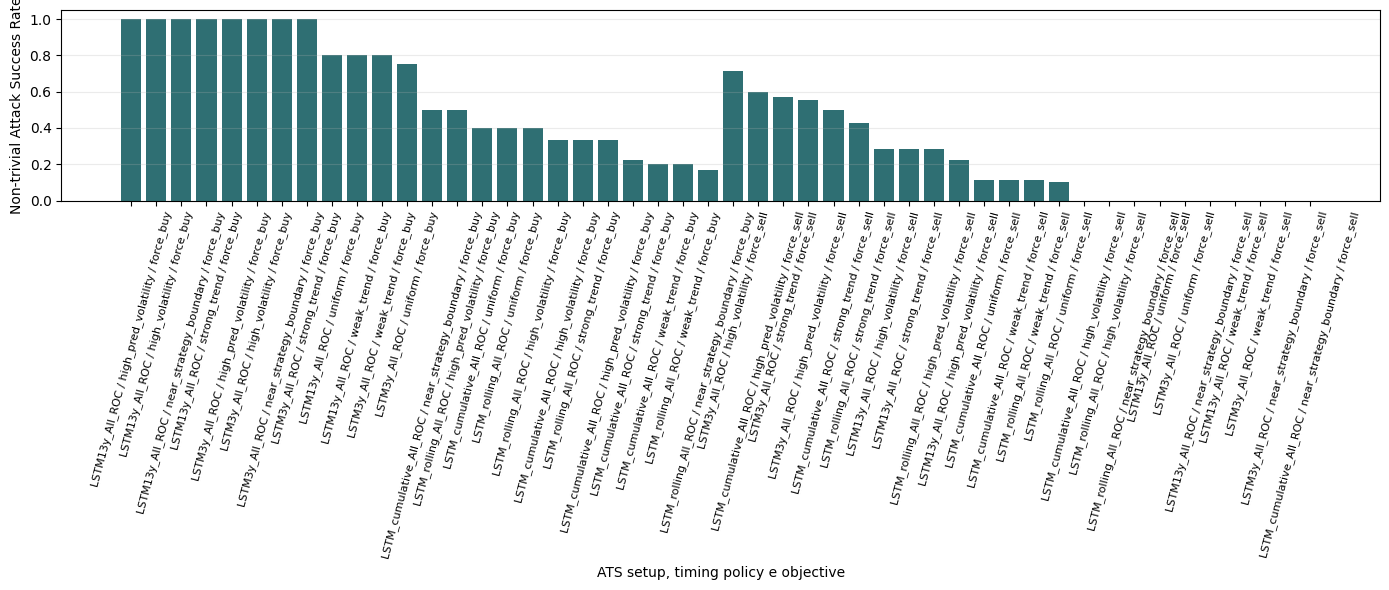

In [4]:
RESULTS_DIR = NOTEBOOK_DIR / "results_targeted/ALL_LSTM_ROC"
EXPERIMENT_NAME = "ALL_LSTM_ROC"

# Load results
results_path = RESULTS_DIR / f"{EXPERIMENT_NAME}.csv"
if results_path.exists():
    print(f"Loading results from: {results_path}")
    results = pd.read_csv(results_path)
else:
    print(f"Error: {results_path} not found.")

_analyze(results)